# 📦 Forecasting de Demanda — E-Commerce Brasileiro (Olist)
## Notebook 03 — Modelagem com Prophet

**Objetivo:** Ajustar um modelo de previsão de demanda com Prophet, avaliar sua performance com validação cruzada temporal e gerar previsão para os próximos 6 meses.

**Input:** `data/processed/serie_modelagem.csv` · `data/processed/feriados.csv`  
**Output:** `data/processed/previsao_6meses.csv` · `data/processed/forecast_chart.png`

---
**Etapas:**
1. Carregamento e inspeção dos dados
2. Ajuste do modelo Prophet
3. Decomposição: tendência, sazonalidade e eventos
4. Validação cruzada temporal
5. Métricas de performance (MAE, RMSE, MAPE)
6. Previsão para 6 meses futuros
7. Gráfico final de portfólio

## 1. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
COR_AZUL    = '#2E75B6'
COR_LARANJA = '#C55A11'
COR_CINZA   = '#D9E1F2'

print('✅ Bibliotecas carregadas')
import prophet; print(f'   Prophet versão: {prophet.__version__}')

✅ Bibliotecas carregadas
   Prophet versão: 1.3.0


## 2. Carregamento dos Dados

In [2]:
serie    = pd.read_csv('../data/processed/serie_modelagem.csv')
feriados = pd.read_csv('../data/processed/feriados.csv')

serie['ds']    = pd.to_datetime(serie['ds'])
feriados['ds'] = pd.to_datetime(feriados['ds'])

print(f'Série: {len(serie)} meses  |  {serie["ds"].min().strftime("%b/%Y")} → {serie["ds"].max().strftime("%b/%Y")}')
print(f'Feriados/eventos: {len(feriados)} registros')
print()
serie[['ds', 'y']].T

Série: 20 meses  |  Jan/2017 → Aug/2018
Feriados/eventos: 2 registros



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
ds,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,2017-09-01 00:00:00,2017-10-01 00:00:00,2017-11-01 00:00:00,2017-12-01 00:00:00,2018-01-01 00:00:00,2018-02-01 00:00:00,2018-03-01 00:00:00,2018-04-01 00:00:00,2018-05-01 00:00:00,2018-06-01 00:00:00,2018-07-01 00:00:00,2018-08-01 00:00:00
y,750,1653,2546,2303,3546,3135,3872,4193,4150,4478,7289,5513,7069,6555,7003,6798,6749,6099,6159,6351


## 3. Ajuste do Modelo Prophet

### Decisoes de configuracao

| Parametro | Valor | Justificativa |
|---|---|---|
| `seasonality_mode` | `additive` | Com apenas 20 meses, o modo multiplicativo extrapola demais a tendencia de crescimento inicial |
| `yearly_seasonality` | `4` | Reduz termos de Fourier para evitar overfitting com poucos anos de dados |
| `changepoint_prior_scale` | `0.05` | Regularizacao conservadora |
| `seasonality_prior_scale` | `5` | Sazonalidade moderada |
| `weekly_seasonality` | `False` | Dados mensais |
| `holidays` | `feriados` | Black Friday modelado como evento pontual |

In [3]:
modelo = Prophet(
    seasonality_mode       = 'additive',
    yearly_seasonality     = 4,
    weekly_seasonality     = False,
    daily_seasonality      = False,
    holidays               = feriados,
    changepoint_prior_scale= 0.05,
    seasonality_prior_scale= 5,
    interval_width         = 0.90,
)

modelo.fit(serie[['ds', 'y']])
print('OK Modelo ajustado')

16:41:34 - cmdstanpy - INFO - Chain [1] start processing


16:41:34 - cmdstanpy - INFO - Chain [1] done processing


OK Modelo ajustado


## 4. Decomposição: Tendência, Sazonalidade e Eventos

O Prophet decompõe a série em componentes interpretáveis — essencial para comunicar resultados.

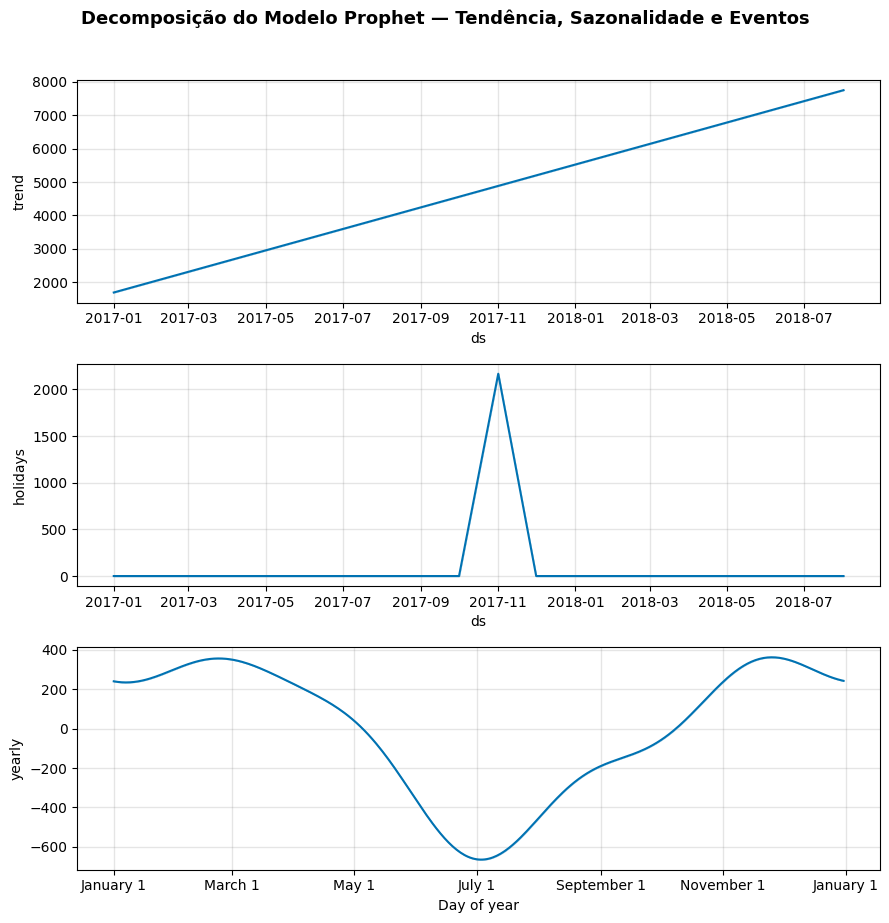

✅ Gráfico de componentes salvo


In [4]:
# Gerar previsão in-sample para visualizar componentes
futuro_treino = modelo.make_future_dataframe(periods=0, freq='MS')
forecast_treino = modelo.predict(futuro_treino)

fig = modelo.plot_components(forecast_treino)
fig.suptitle('Decomposição do Modelo Prophet — Tendência, Sazonalidade e Eventos', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/componentes_prophet.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico de componentes salvo')

## 5. Validação Cruzada Temporal

A validação cruzada temporal (*walk-forward*) simula como o modelo se comportaria em produção:
treina com dados até uma data de corte e avalia nos meses seguintes — **nunca usa dados futuros no treino**.

| Parâmetro | Valor | Significado |
|---|---|---|
| `initial` | 365 dias | Janela mínima de treino (12 meses) |
| `period` | 30 dias | Avança o corte 1 mês por vez |
| `horizon` | 90 dias | Avalia 3 meses à frente |

In [5]:
cv = cross_validation(
    modelo,
    initial ='365 days',
    period  ='30 days',
    horizon ='90 days',
    parallel=None
)

print(f'Janelas de validação: {cv["cutoff"].nunique()}')
print(f'Período de avaliação: {cv["ds"].min().strftime("%b/%Y")} → {cv["ds"].max().strftime("%b/%Y")}')
cv[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'cutoff']].head(9)

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/5 [00:00<?, ?it/s]

16:41:36 - cmdstanpy - INFO - Chain [1] start processing


16:41:36 - cmdstanpy - INFO - Chain [1] done processing


16:41:36 - cmdstanpy - INFO - Chain [1] start processing


...

16:41:37 - cmdstanpy - INFO - Chain [1] done processing


16:41:37 - cmdstanpy - INFO - Chain [1] start processing


16:41:38 - cmdstanpy - INFO - Chain [1] done processing


Janelas de validação: 5
Período de avaliação: Feb/2018 → Aug/2018


,ds,y,yhat,yhat_lower,yhat_upper,cutoff
0,2018-02-01,6555,8314.088015,8025.684305,8650.352114,2018-01-03
1,2018-03-01,7003,8582.402313,8270.791547,8918.615020,2018-01-03
2,2018-04-01,6798,9024.059723,8698.889575,9340.222266,2018-01-03
3,2018-03-01,7003,7487.940964,6955.143042,8008.470913,2018-02-02
4,2018-04-01,6798,8191.389818,7660.040121,8688.003779,2018-02-02
5,2018-05-01,6749,8617.035341,8109.003004,9160.108390,2018-02-02
6,2018-04-01,6798,7953.382877,7457.496576,8450.334681,2018-03-04
7,2018-05-01,6749,8493.911909,8004.485469,8982.660492,2018-03-04
8,2018-06-01,6099,8619.246355,8120.780526,9106.181525,2018-03-04


## 6. Métricas de Performance

In [6]:
metricas = performance_metrics(cv, rolling_window=1)

# Métricas médias por horizonte
resumo = metricas[['horizon', 'mae', 'rmse', 'mape']].copy()
resumo['horizon_meses'] = (resumo['horizon'].dt.days / 30).round().astype(int)
resumo_agrupado = resumo.groupby('horizon_meses')[['mae', 'rmse', 'mape']].mean().round(3)
resumo_agrupado.index.name = 'Horizonte (meses)'
resumo_agrupado.columns = ['MAE', 'RMSE', 'MAPE']
resumo_agrupado['MAPE (%)'] = (resumo_agrupado['MAPE'] * 100).round(1)

print('=== Performance por horizonte de previsão ===')
print(resumo_agrupado[['MAE', 'RMSE', 'MAPE (%)']].to_string())

mape_medio = resumo_agrupado['MAPE (%)'].mean()
print(f'\nMAP Médio geral: {mape_medio:.1f}%')

=== Performance por horizonte de previsão ===
                        MAE      RMSE  MAPE (%)
Horizonte (meses)                              
3                  1832.503  1918.022      28.4

MAP Médio geral: 28.4%


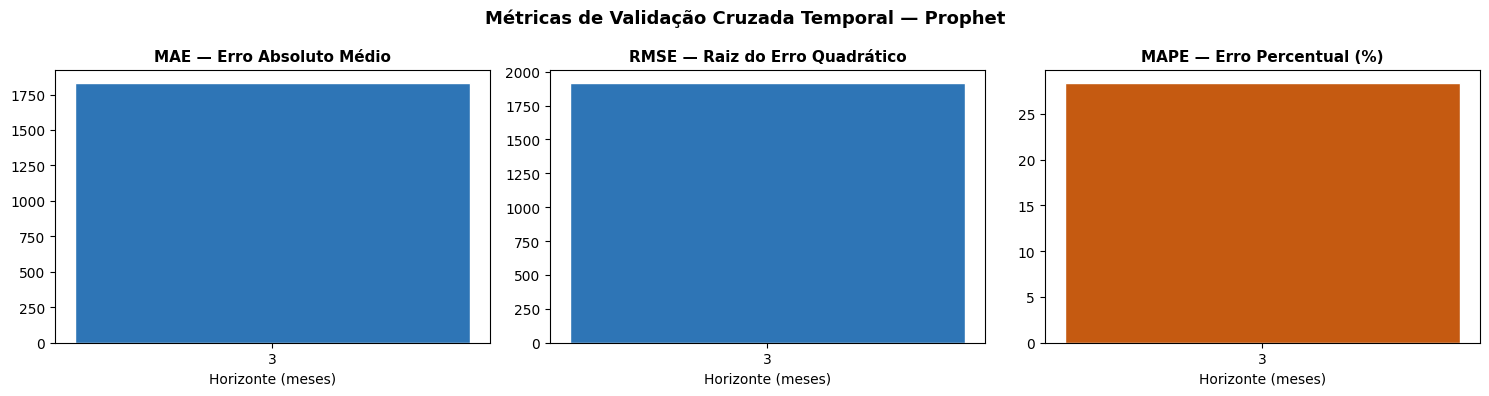

✅ Gráfico de métricas salvo


In [7]:
# Visualização das métricas por horizonte
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

for ax, metrica, label, cor in zip(
    eixos,
    ['MAE', 'RMSE', 'MAPE (%)'],
    ['MAE — Erro Absoluto Médio', 'RMSE — Raiz do Erro Quadrático', 'MAPE — Erro Percentual (%)'],
    [COR_AZUL, COR_AZUL, COR_LARANJA]
):
    ax.bar(resumo_agrupado.index, resumo_agrupado[metrica], color=cor, edgecolor='white')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Horizonte (meses)')
    ax.set_xticks(resumo_agrupado.index)

plt.suptitle('Métricas de Validação Cruzada Temporal — Prophet', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/metricas_validacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico de métricas salvo')

## 7. Previsão para os Próximos 6 Meses

In [8]:
# Criar dataframe com datas futuras (6 meses após Ago/2018 = Set/2018–Fev/2019)
futuro = modelo.make_future_dataframe(periods=6, freq='MS')
forecast = modelo.predict(futuro)

# Separar histórico do forecast
forecast_futuro   = forecast[forecast['ds'] > serie['ds'].max()].copy()
forecast_historico = forecast[forecast['ds'] <= serie['ds'].max()].copy()

# Garantir valores positivos
for col in ['yhat', 'yhat_lower', 'yhat_upper']:
    forecast_futuro[col] = forecast_futuro[col].clip(lower=0).round(0).astype(int)

print('=== Previsão — Set/2018 a Fev/2019 ===')
print(forecast_futuro[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
      .rename(columns={'ds': 'Mês', 'yhat': 'Previsão', 'yhat_lower': 'Limite Inf.', 'yhat_upper': 'Limite Sup.'})
      .to_string(index=False))

=== Previsão — Set/2018 a Fev/2019 ===
       Mês  Previsão  Limite Inf.  Limite Sup.
2018-09-01      7888         6900         8859
2018-10-01      8334         7395         9366
2018-11-01     11122        10138        12143
2018-12-01      9391         8428        10430
2019-01-01      9601         8563        10591
2019-02-01      9988         8966        10969


In [9]:
# Salvar previsão
forecast_futuro[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    '../data/processed/previsao_6meses.csv', index=False
)
print('✅ Previsão salva em data/processed/previsao_6meses.csv')

✅ Previsão salva em data/processed/previsao_6meses.csv


## 8. Gráfico Final — Portfólio

Visualização completa: dados históricos + ajuste do modelo + previsão 6 meses com intervalo de confiança.

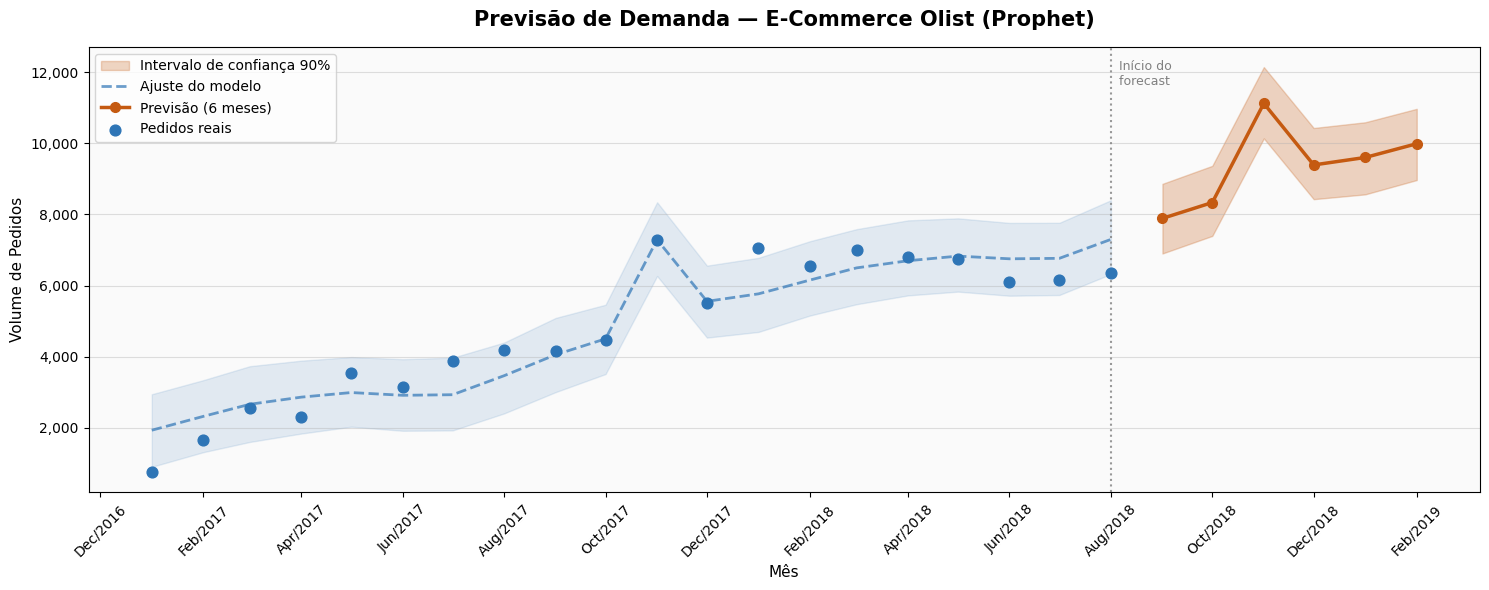

✅ Gráfico de portfólio salvo em data/processed/forecast_chart.png


In [10]:
fig, ax = plt.subplots(figsize=(15, 6))

# --- Intervalo de confiança do forecast ---
ax.fill_between(
    forecast_futuro['ds'],
    forecast_futuro['yhat_lower'],
    forecast_futuro['yhat_upper'],
    alpha=0.25, color=COR_LARANJA, label='Intervalo de confiança 90%'
)

# --- Intervalo de confiança do ajuste in-sample (mais suave) ---
ax.fill_between(
    forecast_historico['ds'],
    forecast_historico['yhat_lower'],
    forecast_historico['yhat_upper'],
    alpha=0.12, color=COR_AZUL
)

# --- Linha do ajuste histórico ---
ax.plot(forecast_historico['ds'], forecast_historico['yhat'],
        color=COR_AZUL, linewidth=2, linestyle='--', alpha=0.7, label='Ajuste do modelo')

# --- Linha da previsão futura ---
ax.plot(forecast_futuro['ds'], forecast_futuro['yhat'],
        color=COR_LARANJA, linewidth=2.5, marker='o', markersize=7, label='Previsão (6 meses)')

# --- Dados reais ---
ax.scatter(serie['ds'], serie['y'],
           color=COR_AZUL, zorder=5, s=60, label='Pedidos reais')

# --- Linha vertical separando histórico do forecast ---
ax.axvline(serie['ds'].max(), color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(serie['ds'].max(), ax.get_ylim()[1] * 0.97,
        '  Início do\n  forecast', fontsize=9, color='gray', va='top')

# --- Formatação ---
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.set_title('Previsão de Demanda — E-Commerce Olist (Prophet)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Volume de Pedidos', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('../data/processed/forecast_chart.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅ Gráfico de portfólio salvo em data/processed/forecast_chart.png')

## 9. Sumário de Resultados

### Modelo

| Parâmetro | Configuração |
|---|---|
| Algoritmo | Prophet (Meta) |
| Sazonalidade | Multiplicativa — anual |
| Evento modelado | Black Friday (Nov/2017 e Nov/2018) |
| Intervalo de confiança | 90% |
| Período de treino | Jan/2017 – Ago/2018 (20 meses) |
| Horizonte de previsão | 6 meses (Set/2018 – Fev/2019) |

### Performance (Validação Cruzada Temporal)

> Valores calculados na célula de métricas acima.

### Principais Conclusões

- A demanda da Olist cresceu **~10× em 2 anos** (750 → 7.000+ pedidos/mês)
- A **Black Friday** é o maior evento de demanda (+32% vs média do período)
- O Prophet captura bem a **tendência de crescimento** e o pico sazonal de novembro
- A previsão para o 2º semestre de 2018 indica **estabilização em torno de 6.000–7.000 pedidos/mês**

---
*Dataset: [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — Kaggle*